In [ ]:
# lpoad basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


##load make_blobs dataset from sklearn library

In [ ]:
from sklearn.datasets import make_blobs

In [ ]:
data=make_blobs(n_samples=1000,n_features=2,centers=1,random_state=23)
data

(array([[ 0.43605162,  8.8453075 ],
        [-0.90254593,  8.58605946],
        [-0.89885039,  8.46964413],
        ...,
        [ 0.28695365,  9.02980717],
        [ 1.55202807,  8.14771456],
        [ 0.56054279, 10.04015118]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 

In [ ]:
x,y=make_blobs(n_samples=1000,n_features=2,centers=1,random_state=23,cluster_std=3.5)
x


array([[ 0.66128648,  8.61044604],
       [-4.02380495,  7.70307792],
       [-4.01087055,  7.29562425],
       ...,
       [ 0.13944358,  9.25619492],
       [ 4.56720406,  6.16887077],
       [ 1.09700556, 12.79239894]])

In [ ]:
x.size

2000

In [ ]:
x.shape

(1000, 2)

In [ ]:
y.size

1000

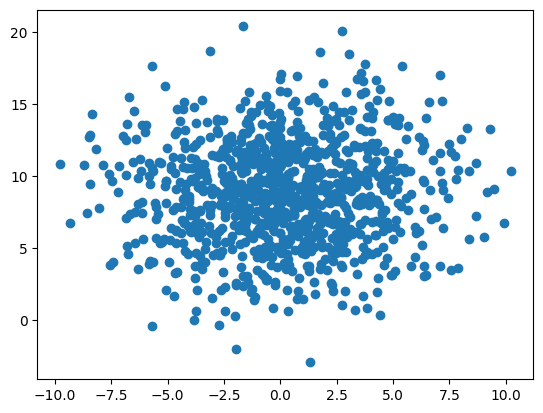

In [ ]:
plt.scatter(x[:,0],x[:,1])

In [ ]:
#split data in train and test variables

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=43)
x_train[1].max()

np.float64(15.265901850427705)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
#model building part
from sklearn.cluster import KMeans

In [ ]:
#Best value of K by using elbow method
k_range=range(1,15)
wcss=[]
for K in k_range:
    kmeans = KMeans(n_clusters=K, init="k-means++", random_state=42, n_init=10) #for centroid we use init   ##(x,y), 2===>(x1,y1)    3==>
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

In [ ]:
wcss

[1399.9999999999986,
 936.9411971788422,
 635.6661758827394,
 498.89774641703514,
 421.2666980672555,
 346.43601311020456,
 302.5396433343054,
 268.87502464381276,
 240.95499907422763,
 214.43949004991333,
 194.76996551387057,
 184.36487798307925,
 168.466542987864,
 158.496138480764]

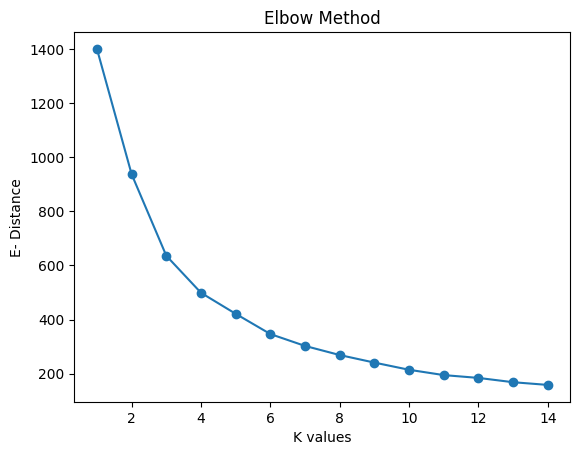

In [ ]:
plt.plot(k_range,wcss,marker="o")
plt.xlabel("K values")
plt.ylabel("E- Distance")
plt.title("Elbow Method")
plt.show()


For K=3

In [ ]:
kmean=KMeans(n_clusters=3,init="k-means++")
y_label=kmean.fit_transform(x_train)
y_label=kmean.labels_

In [ ]:
y_label

array([1, 2, 1, 0, 1, 2, 2, 0, 0, 0, 0, 1, 1, 1, 0, 2, 0, 2, 2, 1, 1, 0,
       0, 2, 1, 0, 2, 1, 0, 1, 1, 1, 2, 1, 2, 1, 0, 1, 2, 0, 0, 2, 2, 1,
       1, 2, 1, 0, 2, 2, 0, 1, 2, 1, 0, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2,
       2, 2, 0, 1, 2, 2, 2, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 2, 0, 1, 1, 1, 1, 2, 1, 0, 1, 1,
       1, 2, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 2, 2, 2, 2, 2, 2, 0, 0, 2, 0,
       0, 1, 0, 2, 1, 0, 0, 1, 2, 0, 0, 2, 0, 0, 2, 0, 1, 1, 1, 0, 1, 2,
       2, 1, 1, 2, 2, 0, 0, 2, 1, 2, 1, 0, 0, 1, 0, 2, 2, 0, 1, 1, 1, 0,
       2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 0,
       1, 1, 2, 1, 1, 0, 0, 1, 2, 0, 0, 1, 2, 2, 2, 0, 0, 1, 1, 1, 2, 0,
       0, 1, 2, 0, 2, 1, 1, 0, 0, 0, 2, 1, 2, 2, 2, 0, 0, 2, 0, 1, 1, 0,
       1, 2, 2, 2, 2, 2, 0, 0, 1, 2, 2, 1, 1, 1, 2, 2, 0, 0, 1, 0, 2, 2,
       2, 2, 2, 0, 0, 1, 2, 1, 2, 2, 0, 2, 1, 1, 2, 0, 0, 2, 1, 2, 2, 2,
       0, 1, 2, 2, 1, 0, 2, 2, 1, 0, 0, 0, 2, 0, 2,

/tmp/ipykernel_9618/1207804110.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


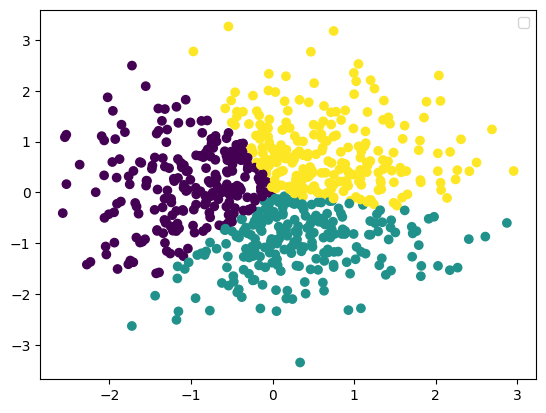

In [ ]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_label)
plt.legend()

Prediction part


In [ ]:
from sklearn.tree import DecisionTreeClassifier


In [ ]:
model = DecisionTreeClassifier()

In [ ]:
model.fit(x_train,y_label)

DecisionTreeClassifier()

In [ ]:
y_test=model.predict(sc.transform(x_test))
y_test

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], d

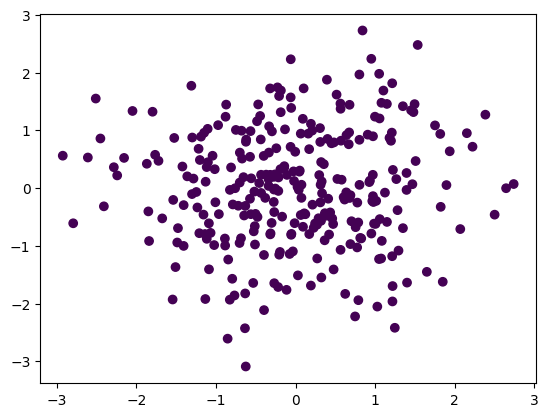

In [ ]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test)

